In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
df=pd.read_csv(r"C:\Users\xhu70\Projects\twel_data_collection\data\sensor_data.csv")

In [3]:
df.head()

,timestamp,temperature_c,humidity_pct,pressure_hpa
0,2026-03-07T18:12:00,27.17,27.88,1012.39
1,2026-03-07T18:12:10,27.16,27.64,1012.42
2,2026-03-07T18:12:20,27.16,27.53,1012.41
3,2026-03-07T18:12:30,27.15,27.39,1012.39
4,2026-03-07T18:12:40,27.15,27.76,1012.44


In [4]:
df["timestamp"]=pd.to_datetime(df["timestamp"])
df=df.set_index("timestamp").resample("5min").mean().reset_index()
df = df.dropna()
df = df.reset_index(drop=True)

In [5]:
a, b = 17.27, 237.7
alpha = (a * df['temperature_c']) / (b + df['temperature_c']) + np.log(df['humidity_pct'] / 100)
df['dewpoint'] = (b * alpha) / (a - alpha)
df["differences"]=df["temperature_c"]-df['dewpoint']


In [6]:
df["hour_sin"]=np.sin(2*np.pi*df["timestamp"].dt.hour/24)
df["hour_cos"]=np.cos(2*np.pi*df["timestamp"].dt.hour/24)
df["pressure_tendency"] = df["pressure_hpa"].diff(6)  # 30分钟内的气压变化
df["humidity_tendency"] = df["differences"].diff(6)
df["temperature_tendency"]=df["temperature_c"].diff(6)

In [7]:
features=["temperature_c",'pressure_tendency',"humidity_tendency","dewpoint"]

In [8]:
HORIZON=6
LOOKBACK=12
TARGET="temperature_c"

In [9]:
def make_dataset(df,horizon,lookback,target,features):

    X,y,y_current=[],[],[]

    data=df[features]
    tgt=df[target]
    
    for i in range(lookback, len(df)-horizon):
        if data[i-lookback:i+horizon]["temperature_c"].max() > 35:
            continue
    # 判断2：这段时间是否连续
        if df["timestamp"].iloc[i] - df["timestamp"].iloc[i-1] > pd.Timedelta("10min"):
            continue
        # 目标值也不能是异常值
        if tgt[i + horizon] > 35:
            continue
        X.append(data[i-lookback:i].values.flatten())
        y.append(tgt[i+horizon])
        y_current.append(tgt[i])
    
    return X,y,y_current

In [10]:
X,y,y_naive= make_dataset(df,HORIZON,LOOKBACK,TARGET,features)


In [11]:
split_train = int(0.6 * len(X))
split_val   = int(0.8 * len(X))

X_train = X[:split_train]
y_train = y[:split_train]

X_val   = X[split_train:split_val]
y_val   = y[split_train:split_val]

X_test  = X[split_val:]
y_test  = y[split_val:]


In [12]:
import xgboost as xgb

In [13]:
model=xgb.XGBRegressor(n_estimators=500, learning_rate=0.04, max_depth=3,early_stopping_rounds=20,random_state=42)
model.fit(X_train,y_train,eval_set=[(X_val,y_val)])

[0]	validation_0-rmse:2.80823
[1]	validation_0-rmse:2.71020
[2]	validation_0-rmse:2.61882
[3]	validation_0-rmse:2.52738
[4]	validation_0-rmse:2.44319
[5]	validation_0-rmse:2.36467
[6]	validation_0-rmse:2.28892
[7]	validation_0-rmse:2.21711
[8]	validation_0-rmse:2.14865
[9]	validation_0-rmse:2.07447
[10]	validation_0-rmse:2.00702
[11]	validation_0-rmse:1.94767
[12]	validation_0-rmse:1.89024
[13]	validation_0-rmse:1.82853
[14]	validation_0-rmse:1.75707
[15]	validation_0-rmse:1.68005
[16]	validation_0-rmse:1.62764
[17]	validation_0-rmse:1.57246
[18]	validation_0-rmse:1.53218
[19]	validation_0-rmse:1.48708
[20]	validation_0-rmse:1.43723
[21]	validation_0-rmse:1.39612
[22]	validation_0-rmse:1.34327
[23]	validation_0-rmse:1.29709
[24]	validation_0-rmse:1.26273
[25]	validation_0-rmse:1.21837
[26]	validation_0-rmse:1.17520
[27]	validation_0-rmse:1.14582
[28]	validation_0-rmse:1.11008
[29]	validation_0-rmse:1.08823
[30]	validation_0-rmse:1.05231
[31]	validation_0-rmse:1.01835
[32]	validation_0-

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",20
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [14]:
y_pred=model.predict(X_test)

In [15]:
from sklearn.metrics import mean_squared_error

In [ ]:
mask = np.array(y_test) < 500
rmse1 = np.sqrt(mean_squared_error(
    np.array(y_pred)[mask],
    np.array(y_test)[mask]
))

y_naive_test = np.array(y_naive)[split_val:]  # 先截取测试集部分
rmse2 = np.sqrt(mean_squared_error(
    y_naive_test[mask],
    np.array(y_test)[mask]
))

print(f"XGBoost RMSE:        {rmse1:.4f}°C")
print(f"Naive baseline RMSE: {rmse2:.4f}°C")
print(f"提升: {(rmse2 - rmse1) / rmse2 * 100:.1f}%")

IndexError: boolean index did not match indexed array along axis 0; size of axis is 1812 but size of corresponding boolean axis is 363

In [ ]:
print(rmse1,rmse2)

0.8552924138487308 0.6926584933567695


In [ ]:
y_naive_test = np.array(y_naive)[split_val:]  # 正确截取
y_test_arr = np.array(y_test)

rmse1 = np.sqrt(mean_squared_error(y_pred, y_test_arr))
rmse_naive = np.sqrt(mean_squared_error(y_naive_test, y_test_arr))

print(f"Naive baseline RMSE: {rmse_naive:.4f}°C")
print(f"XGBoost RMSE:        {rmse1:.4f}°C")
print(f"提升: {(rmse_naive - rmse1) / rmse_naive * 100:.1f}%")

ValueError: Found input variables with inconsistent numbers of samples: [0, 363]

C:\Users\xhu70\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 30495 (\N{CJK UNIFIED IDEOGRAPH-771F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\xhu70\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 23454 (\N{CJK UNIFIED IDEOGRAPH-5B9E}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\xhu70\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 20540 (\N{CJK UNIFIED IDEOGRAPH-503C}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\xhu70\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 39044 (\N{CJK UNIFIED IDEOGRAPH-9884}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\xhu70\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py

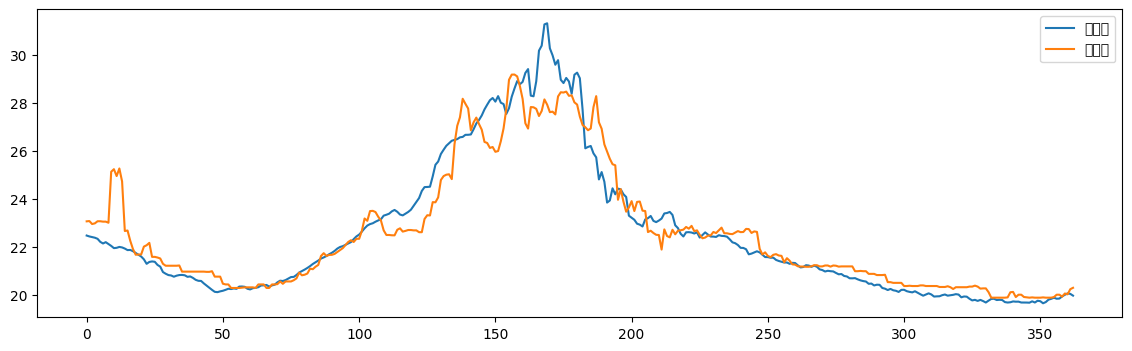

In [ ]:
plt.figure(figsize=(14, 4))
plt.plot(y_test, label="真实值")
plt.plot(y_pred, label="预测值")
plt.legend()
plt.show()

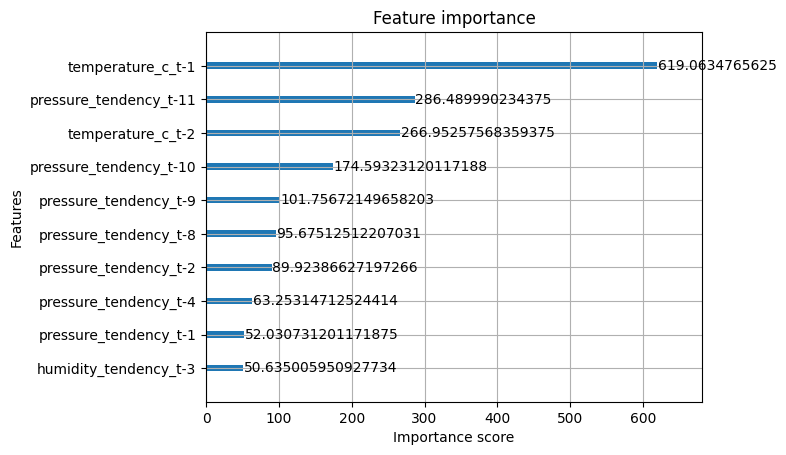

In [ ]:
feature_names = []
for t in range(LOOKBACK, 0, -1):
    for f in features:
        feature_names.append(f"{f}_t-{t}")

model.get_booster().feature_names = feature_names
xgb.plot_importance(model, importance_type="gain", max_num_features=10)
plt.show()